In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time
from sklearn.metrics import confusion_matrix
from sklearn . metrics import ConfusionMatrixDisplay

In [24]:
from sklearn.model_selection import train_test_split

raw_data= pd.read_csv ( './data/Data Intrusion/Train_data.csv'  )

print(raw_data.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

In [25]:
# categorizing any service that appears than the threshold as Other to reduce feature size after generating binary columns for the categories, without this "service" generates 66 columns, with it 33.

threshold = 100

value_counts = raw_data['service'].value_counts()

rare_categories = value_counts[value_counts < threshold].index

raw_data['service'] = raw_data['service'].replace(
    rare_categories, 'Other'
)
print(f"Replaced {len(rare_categories)} rare categories with 'Other'")


Replaced 33 rare categories with 'Other'


In [26]:
data=pd.get_dummies(raw_data, columns=["protocol_type","service","flag","class"], dtype=int)
data=data.drop(columns="class_normal")
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 87 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   src_bytes                    25192 non-null  int64  
 2   dst_bytes                    25192 non-null  int64  
 3   land                         25192 non-null  int64  
 4   wrong_fragment               25192 non-null  int64  
 5   urgent                       25192 non-null  int64  
 6   hot                          25192 non-null  int64  
 7   num_failed_logins            25192 non-null  int64  
 8   logged_in                    25192 non-null  int64  
 9   num_compromised              25192 non-null  int64  
 10  root_shell                   25192 non-null  int64  
 11  su_attempted                 25192 non-null  int64  
 12  num_root                     25192 non-null  int64  
 13  num_file_creatio

In [27]:
from sklearn.preprocessing import StandardScaler


X=data.drop(columns="class_anomaly")
y=data["class_anomaly"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

binary_cols = [col for col in data.columns 
               if data[col].nunique() == 2 and data[col].dtype in ['int64', 'float64']]

continuous_cols = [col for col in data.columns 
                   if data[col].nunique() > 2 and data[col].dtype in ['int64', 'float64', 'float32']]

scaler = StandardScaler()


X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])




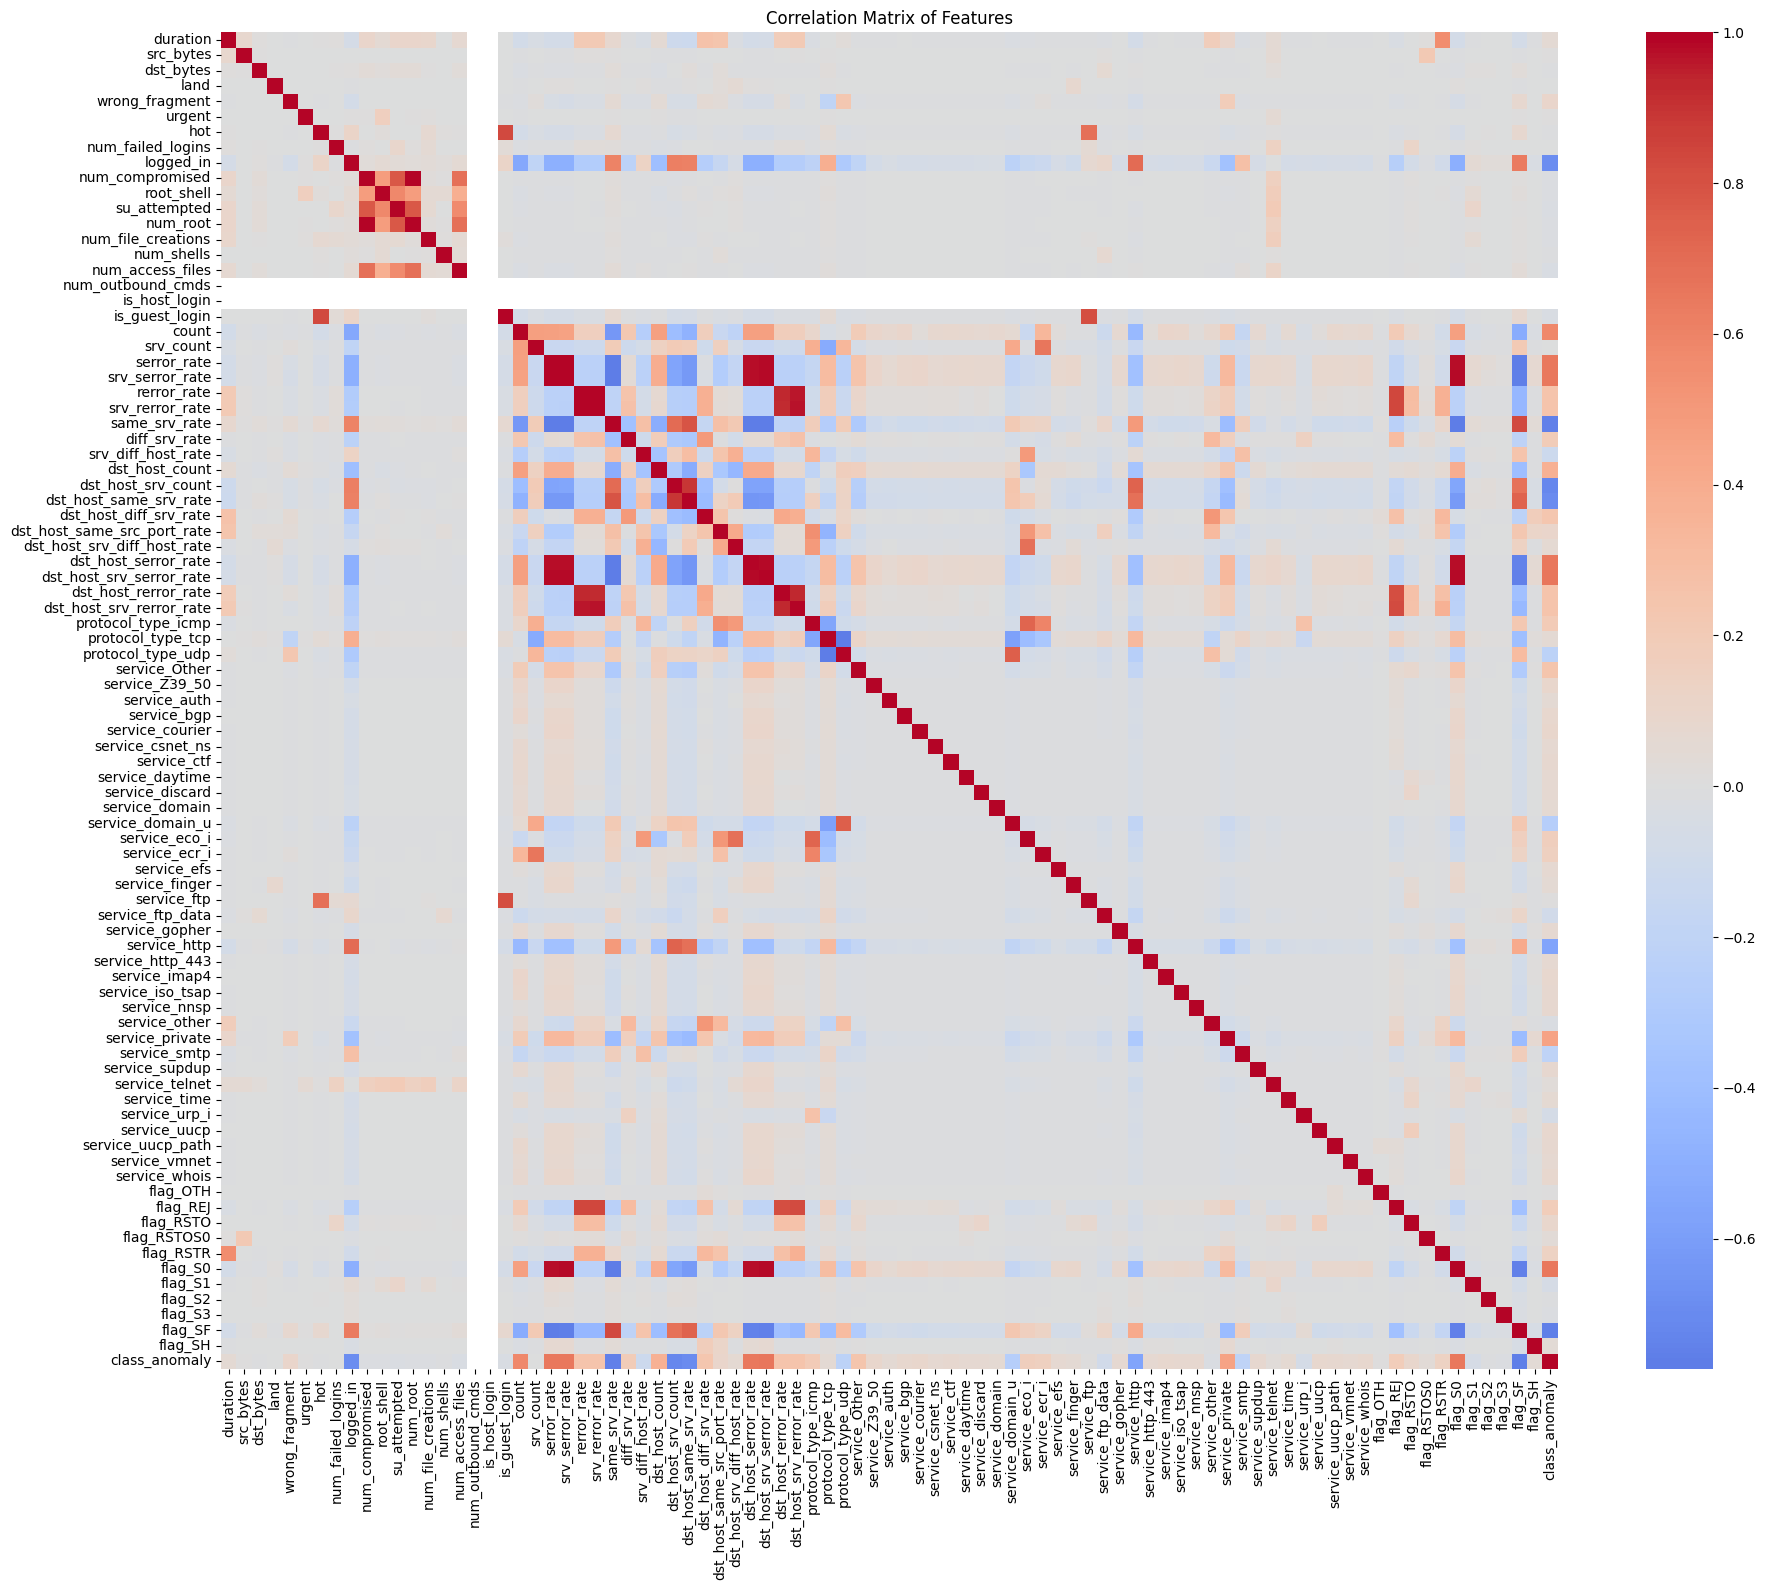

In [28]:
plt.figure(figsize=(20, 16))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()

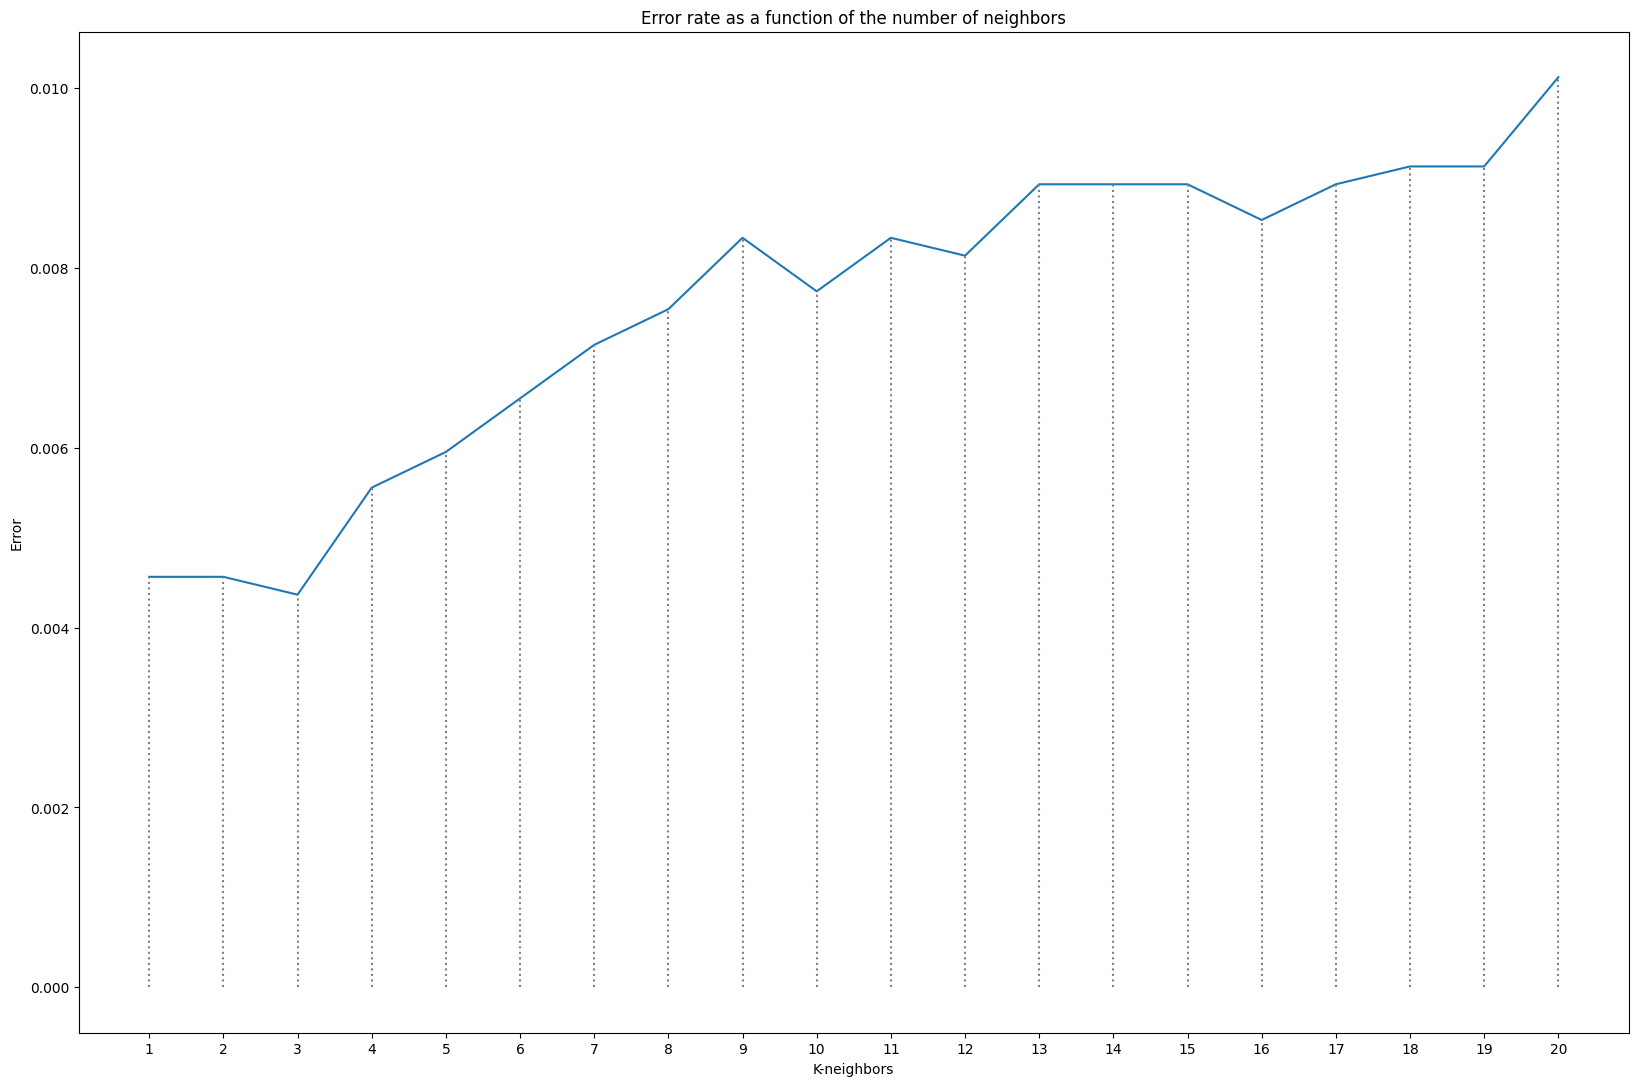

optimal k = 3
error = 0.004366


In [29]:
K=[0] * 20
optimal_k=0
optimal_error=1
for i,k in enumerate(K):
    knn = KNeighborsClassifier(n_neighbors=i+1)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    K[i]=(1-accuracy)
    if K[i]<optimal_error:
        optimal_error= K[i]
        optimal_k=i+1
    
plt.figure(figsize =(20,13))
plt.plot(np.arange(1,21,1), K)
plt.xticks(np.arange(1,21,1))
plt.vlines(np.arange(1,21,1),0, K, linestyle="dotted", color="gray")
plt.xlabel("K-neighbors")
plt.ylabel("Error")
plt.title("Error rate as a function of the number of neighbors")
plt.show()

knn_error=K[optimal_k-1]

print("optimal k =",optimal_k)
print(f"error = {knn_error:.6f}" )

In [30]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_pred=gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
gnb_error=(1-accuracy)

print(f"error = {gnb_error:.6f}" )

error = 0.106569


In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)

lr . fit(X_train, y_train)

y_pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
lr_error=(1-accuracy)

print(f"error = {lr_error:.6f}" )

error = 0.024608


# Comparisons:


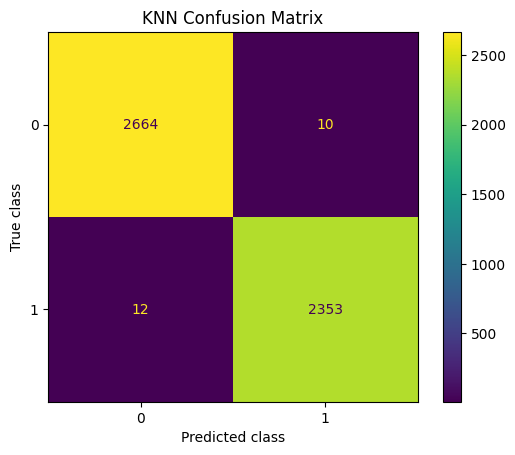

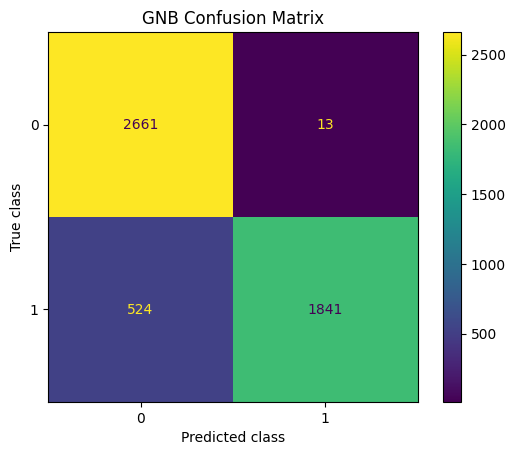

error = 0.024608


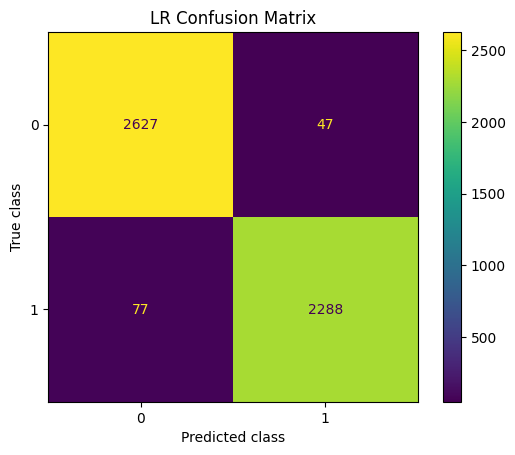

In [32]:
###################### Knn ######################

knn = KNeighborsClassifier(n_neighbors=optimal_k)

start_time = time.time()
knn.fit(X_train, y_train)
end_time = time.time()
training_duration_knn = end_time - start_time

start_time = time.time()
y_pred=knn.predict(X_test)
end_time = time.time()
prediction_time_knn = end_time - start_time
cm = confusion_matrix(y_test, y_pred)

display=ConfusionMatrixDisplay ( confusion_matrix=cm)
display.plot()
plt .xlabel("Predicted class")
plt .ylabel("True class")
plt.title("KNN Confusion Matrix")
plt .show()

###################### LR ######################

gnb = GaussianNB()

start_time = time.time()
gnb.fit(X_train, y_train)
end_time = time.time()
training_duration_gnb = end_time - start_time

start_time = time.time()
y_pred=gnb.predict(X_test)
end_time = time.time()
prediction_time_gnb = end_time - start_time

accuracy = accuracy_score(y_test, y_pred)
gnb_error=(1-accuracy)

cm = confusion_matrix(y_test, y_pred)

display=ConfusionMatrixDisplay ( confusion_matrix=cm )
display.plot()
plt .xlabel("Predicted class")
plt .ylabel("True class")
plt.title("GNB Confusion Matrix")
plt .show()

###################### LR ######################

lr = LogisticRegression(random_state=42, max_iter=1000)

start_time = time.time()
lr . fit(X_train, y_train)
end_time = time.time()
training_duration_lr = end_time - start_time

start_time = time.time()
y_pred = lr.predict(X_test)
end_time = time.time()
prediction_time_lr = end_time - start_time

accuracy = accuracy_score(y_test, y_pred)
lr_error=(1-accuracy)

print(f"error = {lr_error:.6f}" )

cm = confusion_matrix(y_test, y_pred)
display=ConfusionMatrixDisplay ( confusion_matrix=cm )
display.plot()
plt .xlabel("Predicted class")
plt .ylabel("True class")
plt.title("LR Confusion Matrix")
plt .show()


In [33]:
print("Comparisons:")
print("-"*50)
print("Test set error :")
print(f"KNN: {knn_error:.4f}")
print(f"GNB: {gnb_error:.4f}")
print(f"LR: {lr_error:.4f}")
print("-"*50)
print("Training time :")
print(f"KNN: {training_duration_knn:.4f}")
print(f"GNB: {training_duration_gnb:.4f}")
print(f"LR: {training_duration_lr:.4f}")
print("-"*50)
print("Prediction time:")
print(f"KNN: {prediction_time_knn:.4f}")
print(f"GNB: {prediction_time_gnb:.4f}")
print(f"LR: {prediction_time_lr:.4f}")
print("-"*50)

Comparisons:
--------------------------------------------------
Test set error :
KNN: 0.0044
GNB: 0.1066
LR: 0.0246
--------------------------------------------------
Training time :
KNN: 0.0243
GNB: 0.0466
LR: 1.7821
--------------------------------------------------
Prediction time:
KNN: 1.2114
GNB: 0.0138
LR: 0.0063
--------------------------------------------------


## Conslusions:
- KNN had the best accuracy (0.44% error) by finding local patterns, but it's very slow at prediction, over 1 second per run. This makes it accurate but inefficient for real-time use.

- Gaussian Naive Bayes was the least accurate (10.66% error) because its feature independence assumption didn't fit the data well. However, it trained and predicted quickly, useful when speed matters more than precision.

- Logistic Regression balanced speed and accuracy well (2.46% error) and was the fastest at making predictions. Though it took much longer to train, its quick inference makes it practical for deployed systems where predictions must be instant.